#### PE Percentiles

In [140]:
from datetime import datetime
import pandas as pd
import seaborn as sns
import numpy as np

In [141]:
nifty_price_df = pd.read_csv("NIFTY500-Price.csv").dropna()[["Date","Close"]]
nifty_price_df["Date"] = pd.to_datetime(nifty_price_df["Date"]).apply(lambda x:x.date())
nifty_price_df["date_str"] = nifty_price_df["Date"].apply(lambda x:str(x)[:10])

In [142]:
nifty_pe_df = pd.read_csv("NIFTY500-PE.csv").dropna()[["Date","P/E"]]
nifty_pe_df["Date"] = pd.to_datetime(nifty_pe_df["Date"]).apply(lambda x:x.date())
nifty_pe_df["date_str"] = nifty_pe_df["Date"].apply(lambda x:str(x)[:10])

In [143]:
joined_df = nifty_price_df.set_index("date_str").join(nifty_pe_df.set_index("date_str"),how="inner",lsuffix="_l").reset_index()[["Date","Close","P/E"]]

In [144]:
# joined_df = joined_df[joined_df["Date"].apply(lambda x:x > datetime(2010,1,1).date())]

In [168]:
joined_df["PE_3Y"] = joined_df.rolling(1*365)["P/E"].mean()

<Axes: xlabel='Date', ylabel='P/E'>

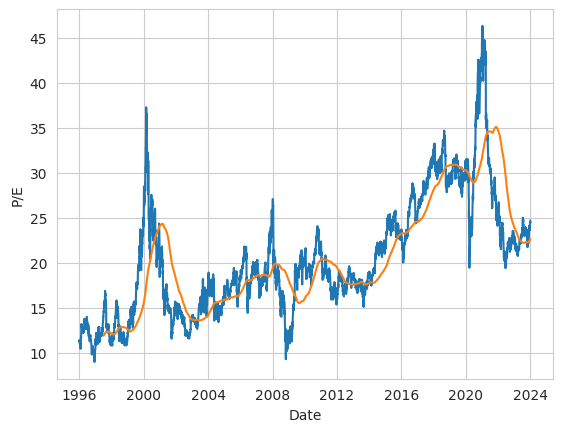

In [169]:
sns.lineplot(x=joined_df["Date"],y=joined_df["P/E"])
sns.lineplot(x=joined_df["Date"],y=joined_df["PE_3Y"])

In [150]:
joined_df.columns

Index(['Date', 'Close', 'P/E'], dtype='object')

In [121]:
joined_df["P/E"].median()

23.305

In [122]:
joined_df["P/E"].std()

6.060190615747393

In [123]:
pe_df = pd.DataFrame(zip(range(0,100,2),np.percentile(joined_df["P/E"],q=range(0,100,2))),
            columns=["perc","pe"])

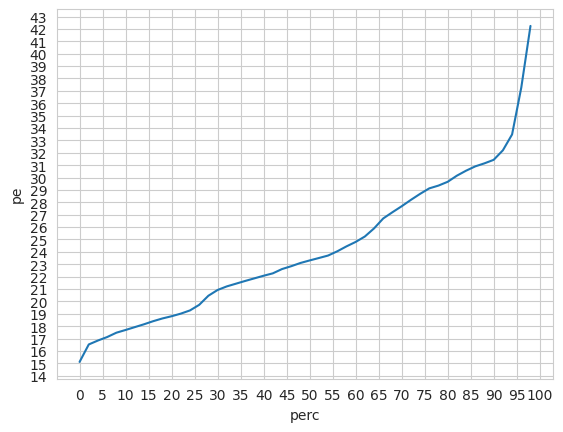

In [124]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
sns.set_style("whitegrid")
ax = sns.lineplot(x=pe_df["perc"],y=pe_df["pe"])
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

In [125]:
nifty_pe_df.iloc[0]

Date        2024-01-05
P/E              24.69
date_str    2024-01-05
Name: 0, dtype: object

#### Next 1 year returns with PE

In [126]:
from dateutil import relativedelta as rd
joined_df["Date+X"] = joined_df["Date"].apply(lambda x:x+rd.relativedelta(years=3))

In [127]:
date_to_price_dict = dict(zip(joined_df["Date"],joined_df["Close"]))
def get_price_from_dict(date):
    if date > datetime.today().date():
        return None
    for i in range(10):
        if date in date_to_price_dict:
            return date_to_price_dict[date]
        else:
            date = date + rd.relativedelta(days=1)
    return None
joined_df["Date+X_Price"] = joined_df["Date+X"].apply(get_price_from_dict)

In [128]:
joined_df1 = joined_df.dropna()

In [129]:
def calculate_cagr(start, end, n):
    cagr = (end / start) ** (1 / n) - 1
    return round(100*cagr,2)
joined_df1["CAGR"] = joined_df1.apply(lambda x:calculate_cagr(x["Close"],x["Date+X_Price"],3),axis=1)

/tmp/ipykernel_1008368/3357622057.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_df1["CAGR"] = joined_df1.apply(lambda x:calculate_cagr(x["Close"],x["Date+X_Price"],3),axis=1)


In [171]:
joined_df1["PE_Quantile"] = pd.qcut(joined_df1["P/E"],q=4)

In [172]:
cagr_vs_PE = pd.DataFrame(joined_df1.groupby("PE_Quantile")["CAGR"].mean()).reset_index()

/tmp/ipykernel_1008368/3545633467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cagr_vs_PE = pd.DataFrame(joined_df1.groupby("PE_Quantile")["CAGR"].mean()).reset_index()


In [173]:
cagr_vs_PE

,PE_Quantile,CAGR
0,"(15.109, 18.77]",15.399111
1,"(18.77, 23.21]",8.513798
2,"(23.21, 29.17]",10.065689
3,"(29.17, 45.24]",14.094963
